In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

# 1. Cargar el dataset
# Asegúrate de que el archivo 'superstore_dataset2012.csv' esté en la misma carpeta que este script
try:
    df = pd.read_csv("1745432818824-superstore_dataset2012.csv", encoding="latin-1")
    print("¡Dataset cargado con éxito!\n")
except UnicodeDecodeError:
    # A veces los archivos de Superstore requieren codificación UTF-8
    df = pd.read_csv("1745432818824-superstore_dataset2012.csv", encoding="utf-8")
    print("¡Dataset cargado con éxito!\n")
    


¡Dataset cargado con éxito!



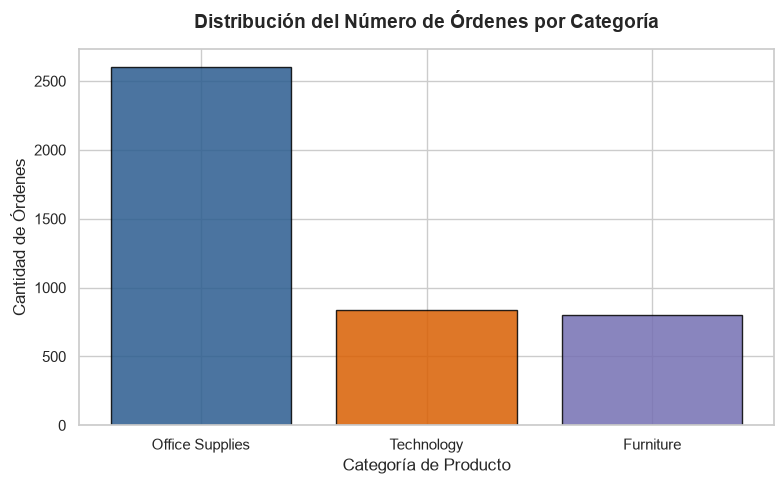

In [15]:
# Asegurar formato datetime para análisis temporal
df["Order Date"] = pd.to_datetime(df["Order Date"])

# ==========================================
# 1. VISUALIZACIÓN UNIVARIANTE CON MATPLOTLIB
# ==========================================
# Diagrama de barras: Frecuencia por Categoría de Producto
plt.figure(figsize=(8, 5))
cat_counts = df["Category"].value_counts()

plt.bar(
    cat_counts.index,
    cat_counts.values,
    color=["#2b5c8f", "#d95f02", "#7570b3"],
    edgecolor="black",
    alpha=0.85,
)
plt.title(
    "Distribución del Número de Órdenes por Categoría",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Categoría de Producto", fontsize=12)
plt.ylabel("Cantidad de Órdenes", fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\n_par\AppData\Local\Temp\ipykernel_42132\1686004855.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


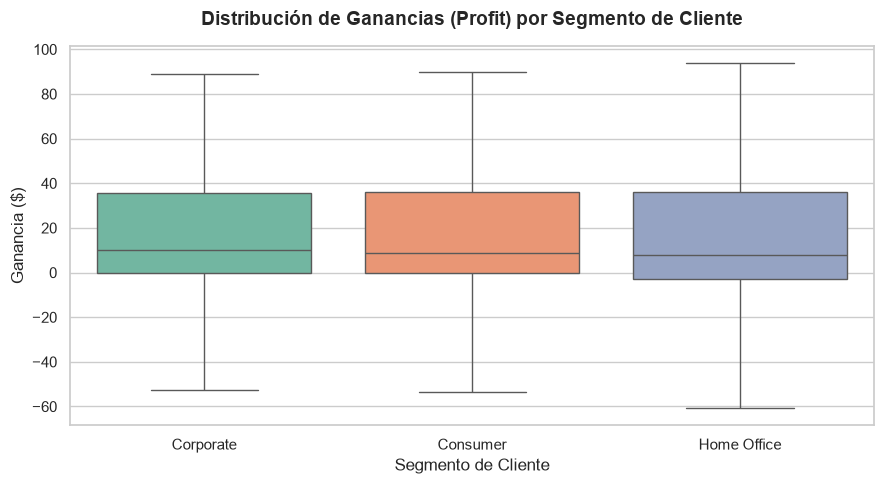

In [16]:
# 2. VISUALIZACIÓN UNIVARIANTE CON SEABORN
# ==========================================
# Boxplot: Distribución de Ganancias (Profit) por Segmento de Cliente
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="Segment",
    y="Profit",
    palette="Set2",
    showfliers=False,  # Ocultamos outliers extremos para mejorar legibilidad
)
plt.title(
    "Distribución de Ganancias (Profit) por Segmento de Cliente",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Segmento de Cliente", fontsize=12)
plt.ylabel("Ganancia ($)", fontsize=12)
plt.tight_layout()
plt.show()

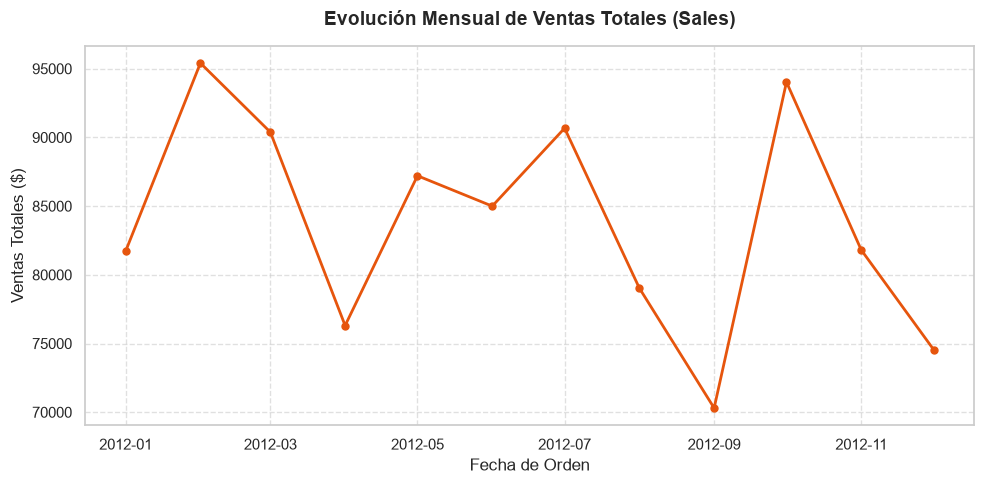

In [17]:
# 3. VISUALIZACIÓN BIVARIANTE CON MATPLOTLIB
# ==========================================
# Gráfico de líneas: Evolución temporal mensual de Ventas Totales
df_monthly = (
    df.set_index("Order Date").resample("MS")["Sales"].sum().reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(
    df_monthly["Order Date"],
    df_monthly["Sales"],
    marker="o",
    color="#e6550d",
    linewidth=2,
    markersize=5,
)
plt.title(
    "Evolución Mensual de Ventas Totales (Sales)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Fecha de Orden", fontsize=12)
plt.ylabel("Ventas Totales ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

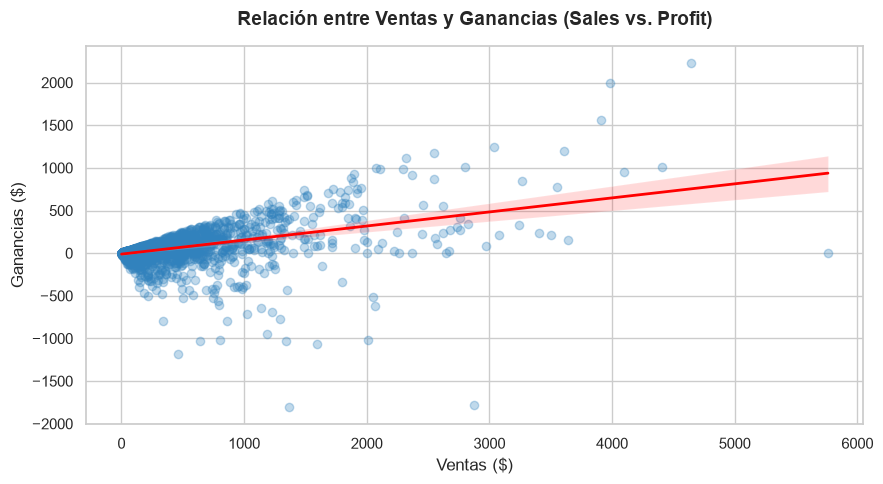

In [18]:
# 4. VISUALIZACIÓN BIVARIANTE CON SEABORN
# ==========================================
# Regplot: Ventas vs. Beneficios con línea de tendencia
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df,
    x="Sales",
    y="Profit",
    scatter_kws={"alpha": 0.3, "color": "#3182bd"},
    line_kws={"color": "red", "linewidth": 2},
)
plt.title(
    "Relación entre Ventas y Ganancias (Sales vs. Profit)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Ventas ($)", fontsize=12)
plt.ylabel("Ganancias ($)", fontsize=12)
plt.tight_layout()
plt.show()

Imagen 'matriz_correlacion_superstore.png' guardada con éxito.


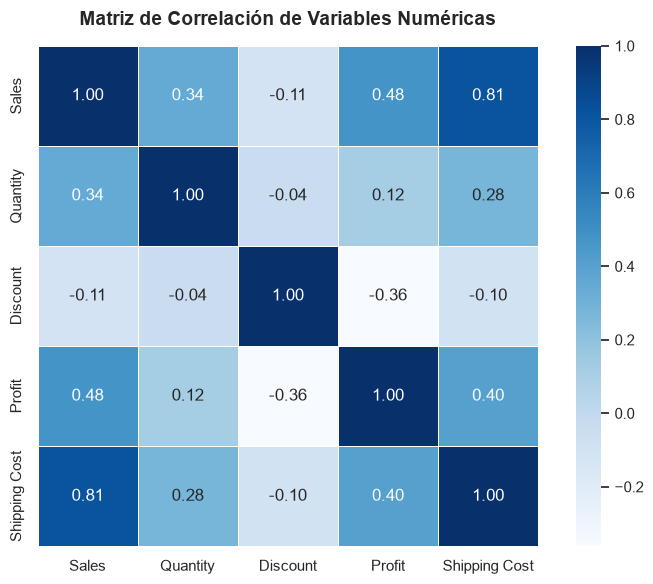

In [19]:
# 5. VISUALIZACIÓN MULTIVARIANTE CON SEABORN
# ==========================================
# Heatmap: Matriz de Correlación
plt.figure(figsize=(8, 6))
numeric_cols = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    square=True,
)
plt.title(
    "Matriz de Correlación de Variables Numéricas",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()

# Guardar esta figura en disco
plt.savefig("matriz_correlacion_superstore.png", dpi=300, bbox_inches="tight")
print("Imagen 'matriz_correlacion_superstore.png' guardada con éxito.")
plt.show()

C:\Users\n_par\AppData\Local\Temp\ipykernel_42132\2293219606.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Dashboard guardado como 'dashboard_superstore.png'


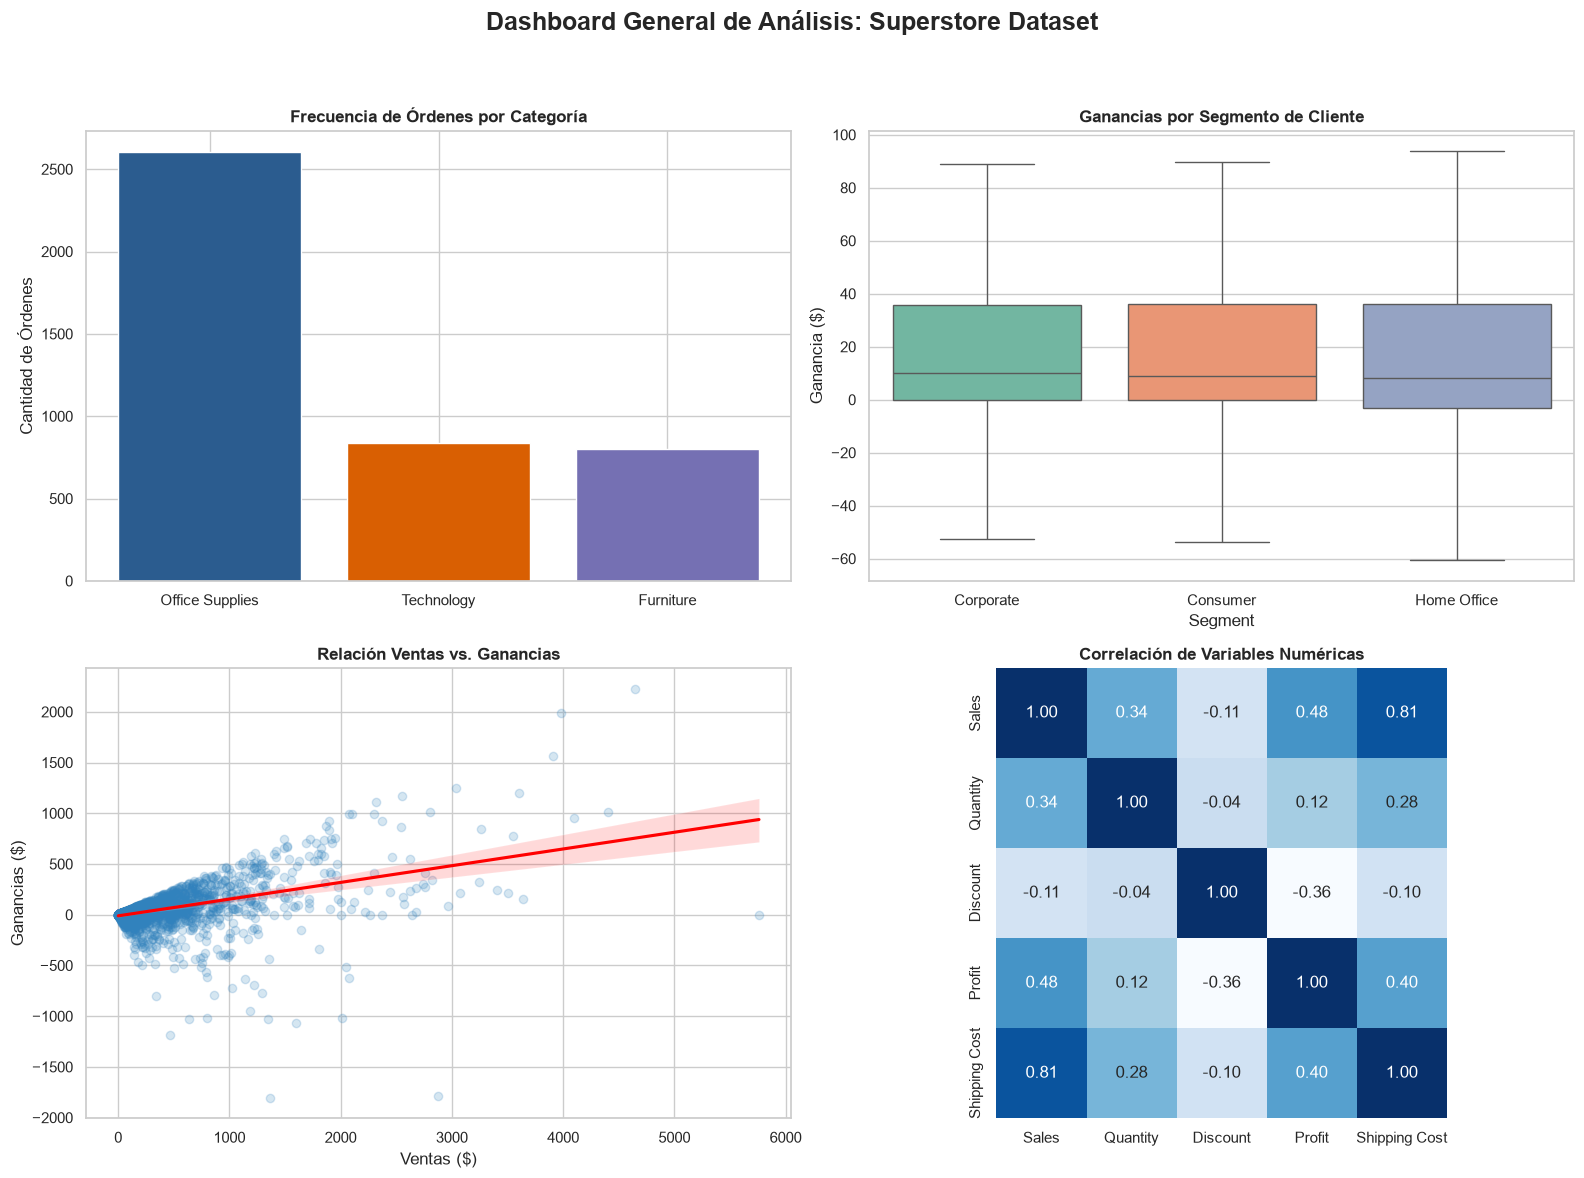

In [20]:
# Creación de la figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Dashboard General de Análisis: Superstore Dataset",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

# --- Subplot 1: Distribución por Categoría (Matplotlib) ---
cat_counts = df["Category"].value_counts()
axes[0, 0].bar(
    cat_counts.index, cat_counts.values, color=["#2b5c8f", "#d95f02", "#7570b3"]
)
axes[0, 0].set_title("Frecuencia de Órdenes por Categoría", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Cantidad de Órdenes")

# --- Subplot 2: Profit por Segmento (Seaborn Boxplot) ---
sns.boxplot(
    data=df,
    x="Segment",
    y="Profit",
    ax=axes[0, 1],
    palette="Set2",
    showfliers=False,
)
axes[0, 1].set_title("Ganancias por Segmento de Cliente", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Ganancia ($)")

# --- Subplot 3: Ventas vs. Beneficios (Seaborn Regplot) ---
sns.regplot(
    data=df,
    x="Sales",
    y="Profit",
    ax=axes[1, 0],
    scatter_kws={"alpha": 0.2, "color": "#3182bd"},
    line_kws={"color": "red"},
)
axes[1, 0].set_title("Relación Ventas vs. Ganancias", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Ventas ($)")
axes[1, 0].set_ylabel("Ganancias ($)")

# --- Subplot 4: Matriz de Correlación (Seaborn Heatmap) ---
corr = df[["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=axes[1, 1],
    cbar=False,
    square=True,
)
axes[1, 1].set_title("Correlación de Variables Numéricas", fontsize=12, fontweight="bold")

# Ajuste de espacio entre subplots
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Guardar la figura del Dashboard
plt.savefig("dashboard_superstore.png", dpi=300, bbox_inches="tight")
print("Dashboard guardado como 'dashboard_superstore.png'")
plt.show()